Feature-Engineered Ensemble SVM using Chi-Squared Approach.

--- Starting EDA ---


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


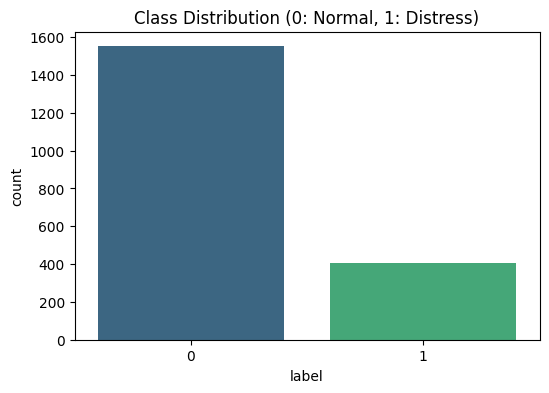

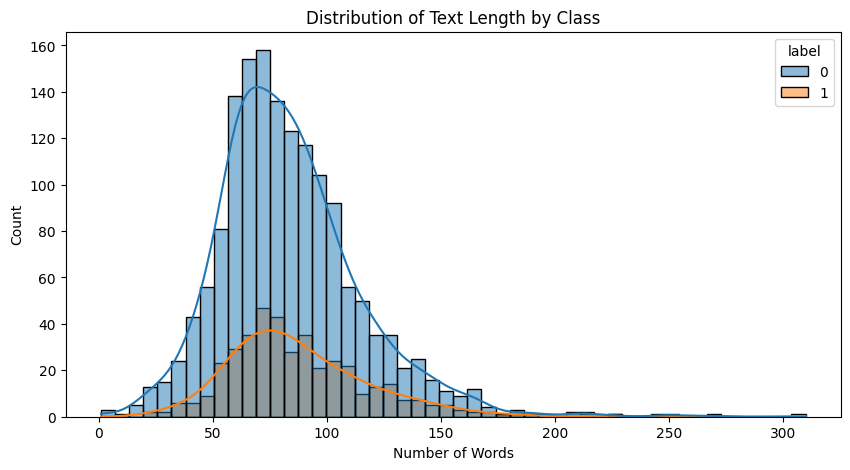

Average Text Length: 84.37 words
Missing Values: 
unique_id    0
text         0
label        0
text_len     0
dtype: int64

=== /content/drive/MyDrive/NLP PROJECT FILES/Binary classification Task/Binarylabel_Train.csv ===
       Count  Percentage (%)
label                       
0       1551           79.25
1        406           20.75
------------------------------

=== /content/drive/MyDrive/NLP PROJECT FILES/Binary classification Task/Binarylabel_Val.csv ===
       Count  Percentage (%)
label                       
0        518           79.33
1        135           20.67
------------------------------

Running Tier 1 Baseline: TF-IDF + SVM (Linear) - Single Split

Training Optimized Ensemble with Feature Selection...

--- Final Optimized Results ---


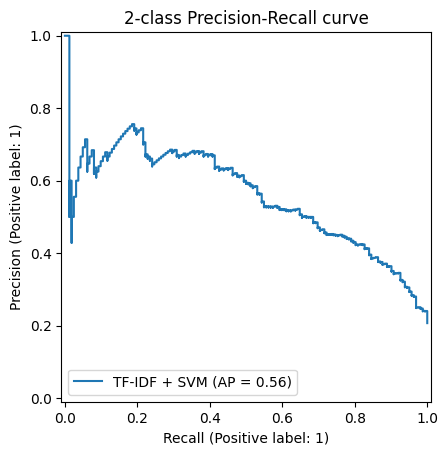

Best Threshold applied: 0.2630
Optimized PR-AUC: 0.5578
Macro F1-score: 0.7257

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87       621
           1       0.52      0.65      0.58       162

    accuracy                           0.80       783
   macro avg       0.71      0.75      0.73       783
weighted avg       0.82      0.80      0.81       783


Confusion Matrix:
[[525  96]
 [ 57 105]]
Inference Complete. Processed 653 rows.
Results saved with original data context in: Final_Test_Results_with_Labels.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install imbalanced-learn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix, f1_score, PrecisionRecallDisplay
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix, f1_score

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


# 1. Load Data
df = pd.read_csv('/content/drive/MyDrive/NLP PROJECT FILES/Binary classification Task/Binarylabel_Train.csv')
df_val = pd.read_csv('/content/drive/MyDrive/NLP PROJECT FILES/Binary classification Task/Binarylabel_Val.csv') # Load validation data separately

X_train_raw = df['text'].values
y_train_raw = df['label'].values

X_val_raw = df_val['text'].values # Use X_val for final testing
y_val_raw = df_val['label'].values # Use y_val for final testing

# Combine train and val for a unified split strategy or keep separate if needed
# For this example, we'll use df for training and df_val as a separate test set later if desired.

# Let's use the df for the main train/test split for the model training
X = df['text'].values
y = df['label'].values

# 1. EXPLORATORY DATA ANALYSIS (EDA)
print("--- Starting EDA ---")

# A. Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', hue='label', data=df, palette='viridis', legend=False)
plt.title('Class Distribution (0: Normal, 1: Distress)')
plt.show()

# B. Sequence Length Analysis
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='text_len', hue='label', kde=True, bins=50)
plt.title('Distribution of Text Length by Class')
plt.xlabel('Number of Words')
plt.show()

print(f"Average Text Length: {df['text_len'].mean():.2f} words")
print(f"Missing Values: \n{df.isnull().sum()}\n")

# 1. Load your datasets (skip this part if they are already loaded in your notebook)
train_path = '/content/drive/MyDrive/NLP PROJECT FILES/Binary classification Task/Binarylabel_Train.csv'
val_path = '/content/drive/MyDrive/NLP PROJECT FILES/Binary classification Task/Binarylabel_Val.csv'

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)

# 2. Define a reusable function to check and print the distribution
def check_label_distribution(df, dataset_name, label_col='label'):
    print(f"=== {dataset_name} ===")

    # Check if the label column exists to avoid errors
    if label_col not in df.columns:
        print(f"Error: Column '{label_col}' not found in the dataset.\n")
        return

    # Calculate raw counts and percentages
    counts = df[label_col].value_counts()
    percentages = df[label_col].value_counts(normalize=True) * 100

    # Combine into a single readable DataFrame for clean output
    distribution_df = pd.DataFrame({
        'Count': counts,
        'Percentage (%)': percentages.round(2)
    })

    print(distribution_df)
    print("-" * 30 + "\n")

# 3. Run the function on your datasets
check_label_distribution(df_train, train_path)
check_label_distribution(df_val, val_path)

# 2. Advanced Vectorization
# We keep stop_words=None to preserve pronouns, but use min_df to cut noise
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1,3), min_df=3, sublinear_tf=True)

# 3. Define the Ensemble Components
# SVM is good for high-dimensional linear patterns
svm_clf = SVC(C=1, kernel='linear', class_weight='balanced', probability=True, random_state=42)

# Random Forest is good for non-linear interactions between words
rf_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

# 4. Create the Pipeline with Feature Selection
# SelectKBest(chi2, k=2000) keeps only the top 2000 most statistically significant features
pipeline = Pipeline([
    ('tfidf', vectorizer),
    ('chi2', SelectKBest(chi2, k=2000)),
    ('ensemble', VotingClassifier(
        estimators=[('svm', svm_clf), ('rf', rf_clf)],
        voting='soft' # Use 'soft' to average the probabilities
    ))
])

# 2. Setup Simple Train-Test Split (Stratified to maintain 79:21 class balance)
# test_size=0.2 means 80% of data goes to training, 20% to testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

print("Running Tier 1 Baseline: TF-IDF + SVM (Linear) - Single Split\n")

# 5. Train the Pipeline
print("Training Optimized Ensemble with Feature Selection...")
pipeline.fit(X_train, y_train)

# 6. Probability-Based Threshold Optimization
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Find threshold that maximizes F1-score on the test set (or validation set)
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_tuned = (y_prob >= best_threshold).astype(int)

# 7. Final Results
print(f"\n--- Final Optimized Results ---")
# Plotting PR-AUC
display = PrecisionRecallDisplay.from_predictions(y_test, y_prob, name="TF-IDF + SVM")
_ = display.ax_.set_title("2-class Precision-Recall curve")
plt.show()
print(f"Best Threshold applied: {best_threshold:.4f}")
print(f"Optimized PR-AUC: {average_precision_score(y_test, y_prob):.4f}")
print(f"Macro F1-score: {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

import pandas as pd
from google.colab import files

# 1. Load the original Test file (to keep all original columns/context)
test_file_path = '/content/Binarylabel_Test.xlsx'
df_test_original = pd.read_excel(test_file_path)

# 2. Extract the text for prediction
# We ensure the text is treated as strings to avoid errors
X_inference = df_test_original['text'].astype(str).values

# 3. Generate Predictions using your TRAINED pipeline
# Note: We use the pipeline directly because it contains both the
# TfidfVectorizer and the Chi2 Feature Selector internally.
y_test_probs = pipeline.predict_proba(X_inference)[:, 1]

# 4. Apply your Optimized Threshold (calculated in the previous step)
# This ensures we maintain the best F1-score balance
y_test_preds = (y_test_probs >= best_threshold).astype(int)

# 5. Integrate results into the original Dataframe
# We add both the discrete label and the probability (confidence score)
# as it is standard practice in DS to see 'how sure' the model was.
df_test_original['predicted_label'] = y_test_preds
df_test_original['prediction_confidence'] = y_test_probs

# 6. Save and Download
output_filename = 'Final_Test_Results_with_Labels.csv'
df_test_original.to_csv(output_filename, index=False)

print(f"Inference Complete. Processed {len(df_test_original)} rows.")
print(f"Results saved with original data context in: {output_filename}")

# Trigger the download
files.download(output_filename)
